In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# 2) Class names for display
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [ ]:
# 3) Reshape & normalize
x_train = x_train.reshape(-1,28,28,1).astype('float32')/255.0
x_test  = x_test.reshape(-1,28,28,1).astype('float32')/255.0

In [ ]:
# 4) One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001), #Adaptive Moment Estimation
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [22]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    verbose=2
)

Epoch 1/20
422/422 - 23s - 55ms/step - accuracy: 0.7996 - loss: 0.5785 - val_accuracy: 0.6882 - val_loss: 0.8503
Epoch 2/20
422/422 - 22s - 53ms/step - accuracy: 0.8656 - loss: 0.3692 - val_accuracy: 0.8822 - val_loss: 0.3051
Epoch 3/20
422/422 - 22s - 53ms/step - accuracy: 0.8831 - loss: 0.3229 - val_accuracy: 0.8740 - val_loss: 0.3300
Epoch 4/20
422/422 - 22s - 53ms/step - accuracy: 0.8920 - loss: 0.2957 - val_accuracy: 0.8993 - val_loss: 0.2744
Epoch 5/20
422/422 - 22s - 53ms/step - accuracy: 0.8992 - loss: 0.2711 - val_accuracy: 0.8903 - val_loss: 0.2857
Epoch 6/20
422/422 - 22s - 53ms/step - accuracy: 0.9049 - loss: 0.2601 - val_accuracy: 0.9010 - val_loss: 0.2622
Epoch 7/20
422/422 - 22s - 53ms/step - accuracy: 0.9106 - loss: 0.2430 - val_accuracy: 0.9020 - val_loss: 0.2616
Epoch 8/20
422/422 - 22s - 53ms/step - accuracy: 0.9119 - loss: 0.2346 - val_accuracy: 0.9085 - val_loss: 0.2628
Epoch 9/20
422/422 - 22s - 53ms/step - accuracy: 0.9191 - loss: 0.2204 - val_accuracy: 0.9043 - 

In [23]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Fashion-MNIST test accuracy: {test_acc*100:.2f}%")

Fashion-MNIST test accuracy: 90.92%


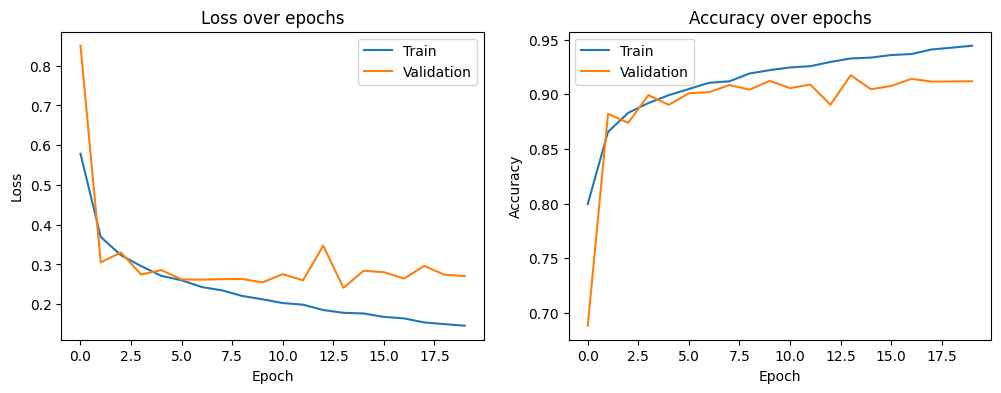

In [24]:
plt.figure(figsize=(12,4))
# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over epochs');
plt.xlabel('Epoch');
plt.ylabel('Loss');
plt.legend()


# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over epochs'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


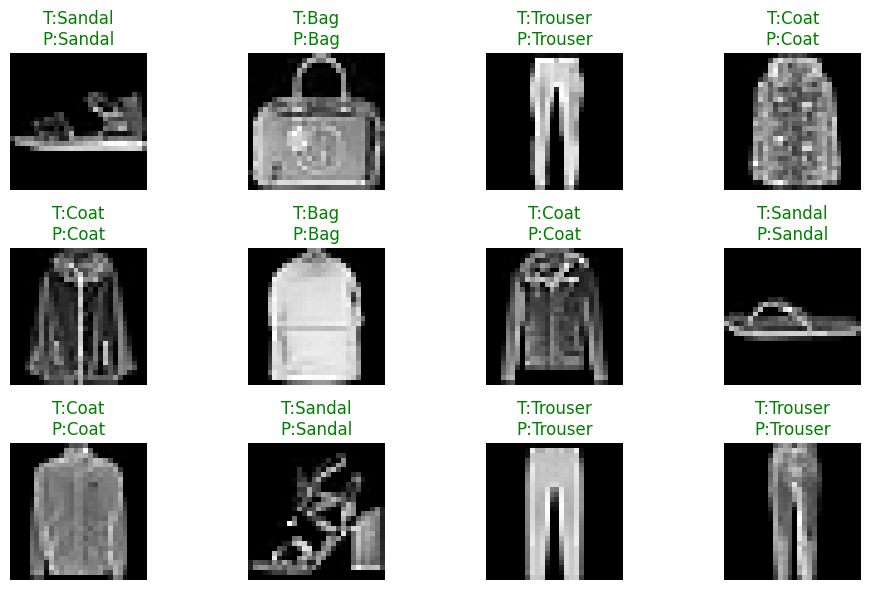

In [25]:
# Pick 12 random test samples
idxs = np.random.choice(len(x_test), size=12, replace=False)
samples = x_test[idxs]
true = np.argmax(y_test[idxs], axis=1)
pred = np.argmax(model.predict(samples), axis=1)

plt.figure(figsize=(10,6))
for i, (img, t, p) in enumerate(zip(samples, true, pred)):
    plt.subplot(3,4,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    color = 'green' if t==p else 'red'
    plt.title(f"T:{class_names[t]}\nP:{class_names[p]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()
